# Import Libraries

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# Load Dataset

In [23]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Explore the Dataset (EDA)

In [24]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [26]:
print(df.shape)

(32561, 15)


In [27]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


# Check data imbalance

In [54]:
print(df["income"].value_counts())

income
<=50K    22654
>50K      7508
Name: count, dtype: int64


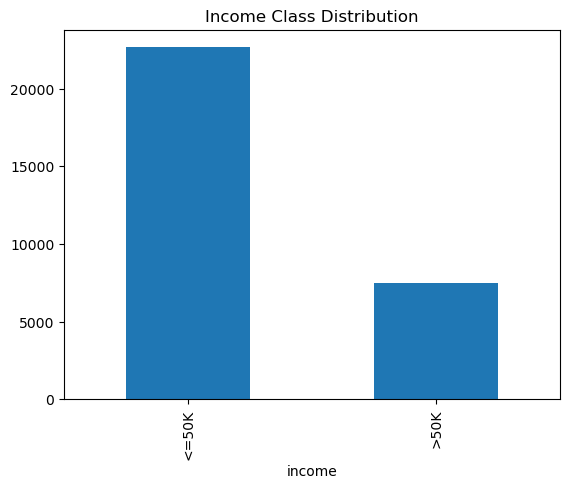

In [55]:
import matplotlib.pyplot as plt

df["income"].value_counts().plot(kind="bar")

plt.title("Income Class Distribution")

plt.show()

## Handle imbalance data

In [56]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(scale_pos_weight)

3.0174825174825175


## Handle Missing Values

In [57]:
df.replace("?", np.nan, inplace=True)

df.dropna(inplace=True)

# Split Features and Target

In [58]:
X = df.drop("income", axis=1)

y = df["income"]

# Encode Target Column

In [59]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

# Identify Numerical and Categorical Columns

In [60]:
categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)

print(numerical_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


# Preprocessing

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Train-Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost Model

In [83]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# Full Pipeline

In [84]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Hyperparameter Grid Search

In [85]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2]
}

## Create GridSearchCV

In [86]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train the Model

In [87]:
grid_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


# Best Parameters

In [88]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 200}


# Predictions

In [89]:
y_pred = grid_search.predict(X_test)

# Evaluate Model

In [90]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.849494447207028
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      4531
           1       0.65      0.84      0.73      1502

    accuracy                           0.85      6033
   macro avg       0.80      0.85      0.81      6033
weighted avg       0.87      0.85      0.86      6033

[[3866  665]
 [ 243 1259]]
